# Laboratorio 5: Clasificación Multiclase con Extracción HOG, Normalización y Red Densa Optimizada en PyTorch

## Solución al Límite de Precisión en Píxeles Crudos mediante Descriptores de Gradientes Orientados (HOG) y Normalización Z-Score

### ¿Por qué la precisión con píxeles crudos es limitada en redes densas?
Al alimentar una red neuronal densa (MLP) con los píxeles directos ($32 \times 32 \times 3 = 3072$), cada neurona queda ligada a una coordenada espacial fija. Si el objeto cambia ligeramente de posición, iluminación o fondo, los valores de los píxeles cambian drásticamente. Las redes densas carecen de invarianza espacial traslacional, provocando que confundan fondos con objetos.

### La Solución Clásica de Visión Artificial: HOG (Histogram of Oriented Gradients)
1. **Captura de Estructura y Bordes:** Divide la imagen en pequeñas celdas ($4 \times 4$ píxeles), calcula la magnitud y ángulo de los gradientes de intensidad en 8 orientaciones espaciales, y normaliza la energía local por bloques ($2 \times 2$ celdas).
2. **Invarianza a la Iluminación:** HOG ignora los cambios globales de color y brillo, reteniendo únicamente las formas y contornos geométricos característicos de cada clase.
3. **Normalización Z-Score ($FeatureNormalize$):** Se calculan los parámetros de media $\mu$ y desviación estándar $\sigma$ **exclusivamente sobre el conjunto de entrenamiento**, proyectando las características HOG a media 0 y varianza 1 para acelerar la convergencia del gradiente y evitar fuga de información (*data leakage*).
4. **Modelo Único: Red Neuronal Densa Optimizada:**
   Un Perceptrón Multicapa Profundo diseñado con las recetas de los **Cuadernillos 06 y 07**:
   $$\text{HOG (1568)} \rightarrow \text{Linear}(512) \rightarrow \mathbf{BatchNorm1d} \rightarrow \text{ReLU} \rightarrow \mathbf{Dropout}(0.2) \rightarrow \text{Linear}(256) \rightarrow \mathbf{BatchNorm1d} \rightarrow \text{ReLU} \rightarrow \mathbf{Dropout}(0.2) \rightarrow \text{Linear}(num\_classes)$$
5. **Diagnóstico Gráfico de la Función de Costo:**
   Se incluye una gráfica detallada de la curva de pérdida (Train Loss vs Val Loss) con un **panel de diagnóstico automatizado** para determinar cuantitativamente si **faltan épocas por iterar**, si se alcanzó la meseta óptima o si existe sobreajuste.

In [1]:
# Esta celda importa librerías para manejo de imágenes, HOG, tensores y evaluación en PyTorch.
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

# Descriptores de visión artificial (HOG)
from skimage.feature import hog

# Objetos centrales de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import torchvision.transforms as transforms

# Métricas del Cuadernillo 08
from sklearn.metrics import accuracy_score, confusion_matrix, top_k_accuracy_score

# Buenas prácticas: Semilla para reproducibilidad científica
def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass
    np.random.seed(seed)

set_seed(42)

# Detección del acelerador de hardware (GPU CUDA o CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo detectado: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'Dispositivo en uso: {device}')

Dispositivo detectado: NVIDIA GeForce RTX 4050 Laptop GPU
Dispositivo en uso: cuda


In [ ]:
# ==============================================================================
# CONFIGURACIÓN GENERAL Y ADAPTABILIDAD DEL DATASET
# (Modifica estas variables para usar cualquier dataset de imágenes)
# ==============================================================================

# 1. Rutas a las carpetas de entrenamiento y prueba
TRAIN_DIR = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio5\cifar100\train'
TEST_DIR  = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio5\cifar100\test'

# 2. Parámetros de Extracción HOG
ORIENTATIONS = 8
PIXELS_PER_CELL = (4, 4)
CELLS_PER_BLOCK = (2, 2)

# 3. Hiperparámetros de Entrenamiento
BATCH_SIZE = 256
EPOCHS = 200    # Suficientes épocas para observar con claridad la curva de costo
PATIENCE = 10    # Tolerancia de épocas antes de Early Stopping
LR = 0.

# Detección automática de clases a partir de las carpetas
clases = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
num_classes = len(clases)

print("=" * 70)
print(f"Dataset detectado: {num_classes} clases encontradas en disco.")
print(f"Ruta Train: {TRAIN_DIR}")
print(f"Ruta Test:  {TEST_DIR}")
print("=" * 70)

Dataset detectado: 100 clases encontradas en disco.
Ruta Train: E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio5\cifar100\train
Ruta Test:  E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio5\cifar100\test


In [34]:
# ==============================================================================
# DESPLIEGUE COMPLETO DE TODAS LAS CLASES DEL DATASET
# ==============================================================================
print(f"Listado estructurado de las {num_classes} clases disponibles:\n")

cols_tabla = 10 if num_classes >= 10 else num_classes
filas_tabla = math.ceil(num_classes / cols_tabla)

lista_formateada = clases + [''] * (filas_tabla * cols_tabla - num_classes)
matriz_clases = np.array(lista_formateada).reshape(filas_tabla, cols_tabla)

df_clases = pd.DataFrame(matriz_clases)
df_clases.columns = [f'C{j}' for j in range(cols_tabla)]
df_clases.index = [f'{i*cols_tabla:02d}-{(i+1)*cols_tabla-1:02d}:' for i in range(filas_tabla)]
print(df_clases.to_string())

Listado estructurado de las 100 clases disponibles:

              C0             C1         C2            C3         C4       C5           C6          C7            C8         C9
00-09:     apple  aquarium_fish       baby          bear     beaver      bed          bee      beetle       bicycle     bottle
10-19:      bowl            boy     bridge           bus  butterfly    camel          can      castle   caterpillar     cattle
20-29:     chair     chimpanzee      clock         cloud  cockroach    couch         crab   crocodile           cup   dinosaur
30-39:   dolphin       elephant   flatfish        forest        fox     girl      hamster       house      kangaroo   keyboard
40-49:      lamp     lawn_mower    leopard          lion     lizard  lobster          man  maple_tree    motorcycle   mountain
50-59:     mouse       mushroom   oak_tree        orange     orchid    otter    palm_tree        pear  pickup_truck  pine_tree
60-69:     plain          plate      poppy     porcupine  

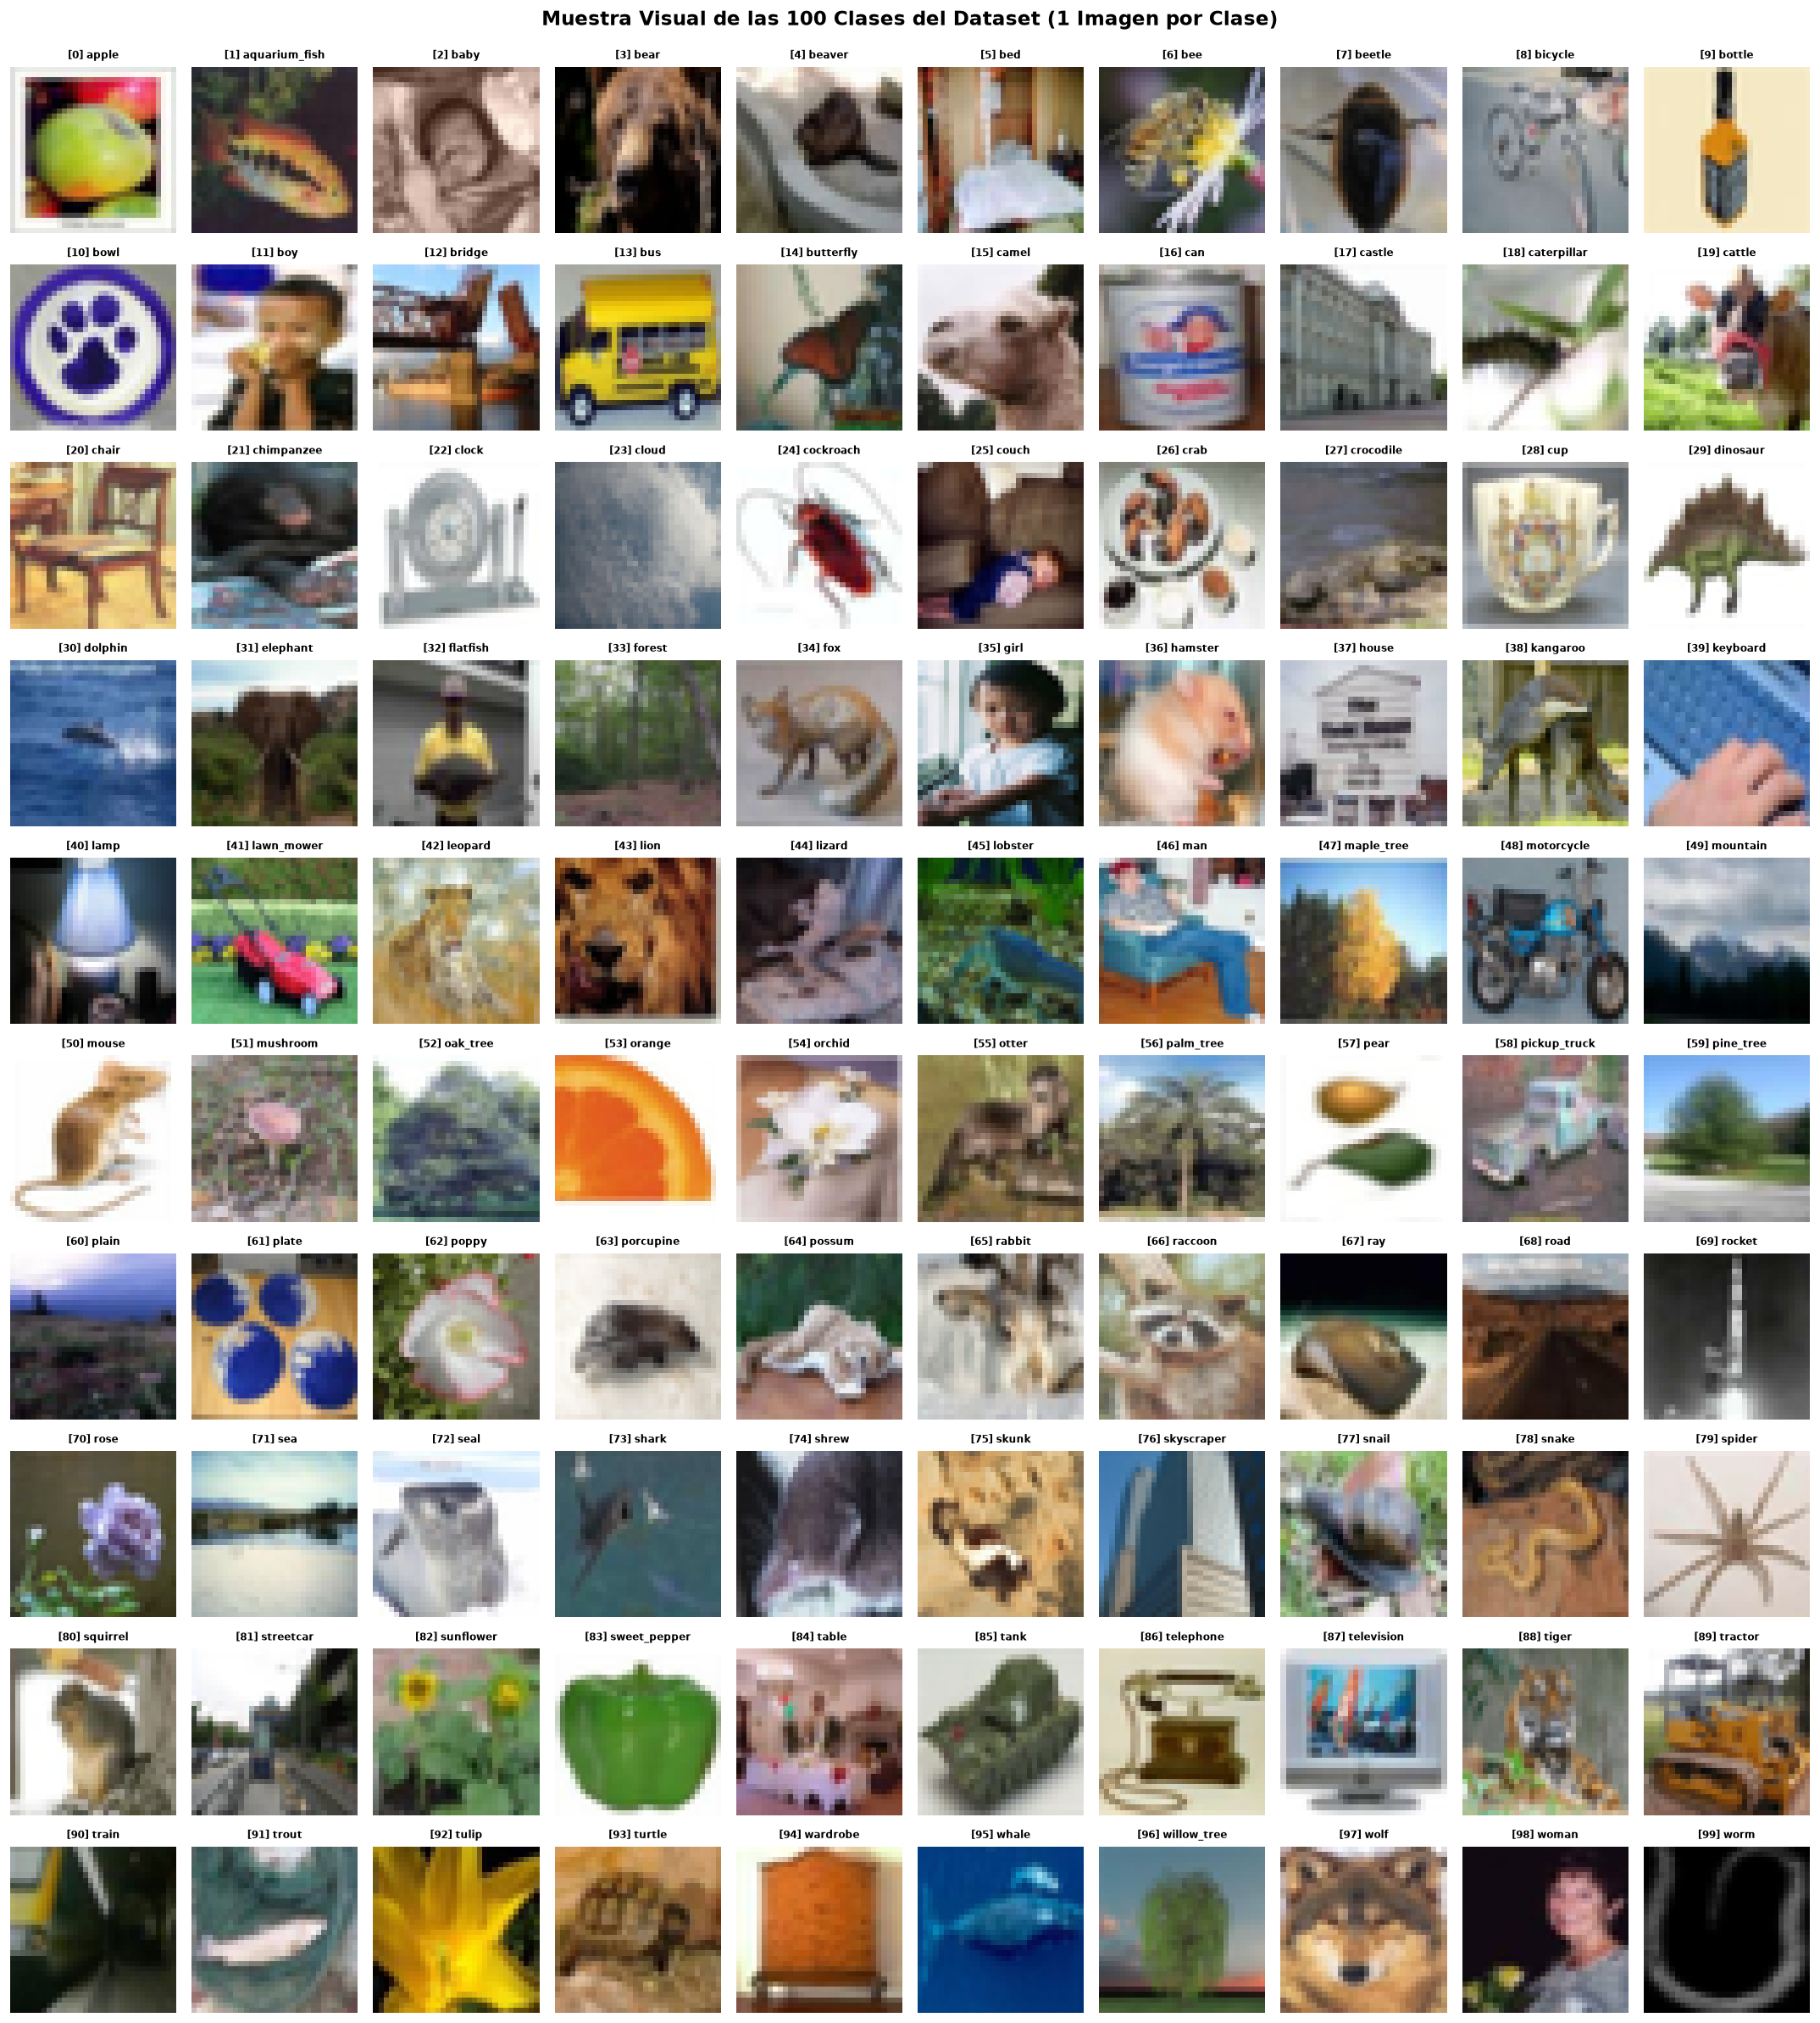

In [35]:
# ==============================================================================
# VISUALIZACIÓN DE TODAS LAS CLASES DEL DATASET (1 IMAGEN POR CADA CLASE)
# ==============================================================================
grid_cols = 10 if num_classes >= 10 else num_classes
grid_rows = math.ceil(num_classes / grid_cols)

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 1.8, grid_rows * 2.0), dpi=120)
axes = np.array(axes).reshape(-1)

for c, nombre_clase in enumerate(clases):
    carpeta_clase = os.path.join(TRAIN_DIR, nombre_clase)
    archivos = [f for f in os.listdir(carpeta_clase) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Cargamos la primera imagen disponible de esta clase
    img_path = os.path.join(carpeta_clase, archivos[0])
    img = Image.open(img_path).convert('RGB')
    
    axes[c].imshow(img)
    axes[c].set_title(f"[{c}] {nombre_clase}", fontsize=7, fontweight='bold')
    axes[c].axis('off')

# Ocultamos ejes sobrantes
for extra in range(num_classes, len(axes)):
    axes[extra].axis('off')

plt.suptitle(f'Muestra Visual de las {num_classes} Clases del Dataset (1 Imagen por Clase)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [36]:
# ==============================================================================
# EXTRACCIÓN DE CARACTERÍSTICAS HOG Y NORMALIZACIÓN Z-SCORE
# ==============================================================================

# Archivos de caché para acelerar ejecuciones posteriores
CACHE_TRAIN_HOG = 'cifar100_hog_train.pt'
CACHE_TEST_HOG  = 'cifar100_hog_test.pt'

def extraer_hog_de_carpeta(folder_path, clases_list):
    X_feats, y_labels = [], []
    t0 = time.time()
    total_imgs = 0
    
    for label_idx, cls_name in enumerate(clases_list):
        cls_dir = os.path.join(folder_path, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        archivos = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for fname in archivos:
            fpath = os.path.join(cls_dir, fname)
            img = Image.open(fpath).convert('RGB')
            arr = np.array(img)
            feat = hog(arr,
                       orientations=ORIENTATIONS,
                       pixels_per_cell=PIXELS_PER_CELL,
                       cells_per_block=CELLS_PER_BLOCK,
                       channel_axis=-1)
            X_feats.append(feat)
            y_labels.append(label_idx)
            total_imgs += 1
            
    X_tensor = torch.tensor(np.array(X_feats, dtype=np.float32))
    y_tensor = torch.tensor(np.array(y_labels, dtype=np.int64))
    print(f"Extracción completada: {total_imgs} imágenes en {time.time()-t0:.1f}s -> Tensor {X_tensor.shape}")
    return X_tensor, y_tensor

# 1. Carga desde caché o extracción
if os.path.exists(CACHE_TRAIN_HOG) and os.path.exists(CACHE_TEST_HOG):
    print("-> Cargando características HOG desde caché local en disco...")
    data_tr = torch.load(CACHE_TRAIN_HOG, map_location='cpu', weights_only=True)
    data_te = torch.load(CACHE_TEST_HOG, map_location='cpu', weights_only=True)
    X_train_hog, y_train = data_tr['features'], data_tr['labels']
    X_test_hog, y_test   = data_te['features'], data_te['labels']
    print(f"Caché cargado exitosamente: Train {X_train_hog.shape} | Test {X_test_hog.shape}")
else:
    print("Extrayendo características HOG de Entrenamiento...")
    X_train_hog, y_train = extraer_hog_de_carpeta(TRAIN_DIR, clases)
    torch.save({'features': X_train_hog, 'labels': y_train}, CACHE_TRAIN_HOG)
    
    print("Extrayendo características HOG de Prueba...")
    X_test_hog, y_test = extraer_hog_de_carpeta(TEST_DIR, clases)
    torch.save({'features': X_test_hog, 'labels': y_test}, CACHE_TEST_HOG)

# 2. Normalización Z-Score (media 0 y desviación estándar 1)
# Calculada ÚNICAMENTE sobre el conjunto de entrenamiento para evitar fuga de información
print("\nAplicando Normalización Z-Score a las características HOG...")
mu = torch.mean(X_train_hog, dim=0)
sigma = torch.std(X_train_hog, dim=0)
sigma[sigma == 0] = 1.0  # Evita división por cero en características constantes

X_train_norm = (X_train_hog - mu) / sigma
X_test_norm  = (X_test_hog - mu) / sigma

print(f"X_train_norm -> Media: {X_train_norm.mean():.4f}, Desviación Estándar: {X_train_norm.std():.4f}")
print(f"X_test_norm  -> Media: {X_test_norm.mean():.4f}, Desviación Estándar: {X_test_norm.std():.4f}")

# 3. Creación de Datasets y DataLoaders de PyTorch
train_dataset = TensorDataset(X_train_norm, y_train)
test_dataset  = TensorDataset(X_test_norm, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

input_dim = X_train_norm.shape[1]
print(f"Dimensión final de entrada para la red neuronal (input_dim): {input_dim}")

-> Cargando características HOG desde caché local en disco...
Caché cargado exitosamente: Train torch.Size([50000, 1568]) | Test torch.Size([10000, 1568])

Aplicando Normalización Z-Score a las características HOG...
X_train_norm -> Media: -0.0000, Desviación Estándar: 1.0000
X_test_norm  -> Media: 0.0000, Desviación Estándar: 1.0000
Dimensión final de entrada para la red neuronal (input_dim): 1568


In [37]:
# ==============================================================================
# SANITY CHECK Y VERIFICACIÓN INICIAL (RECETA CUADERNILLO 07)
# ==============================================================================

# 1. Comprobación dimensional de entrada y salida
test_x = torch.randn((16, input_dim)).to(device)
test_model_check = nn.Sequential(
    nn.Linear(input_dim, num_classes)
).to(device)

test_out = test_model_check(test_x)
print(f"Sanity Check de dimensiones: entrada {test_x.shape} -> salida {test_out.shape}")

# 2. Comprobación del costo teórico inicial (para num_classes equiprobables)
criterion = nn.CrossEntropyLoss()
test_y = torch.randint(0, num_classes, (16,)).to(device)
loss_inicial = criterion(test_out, test_y).item()
loss_teorica = np.log(num_classes)

print(f"Pérdida teórica esperada:  ln({num_classes}) = {loss_teorica:.4f}")
print(f"Pérdida inicial observada: {loss_inicial:.4f}")
print("-> El costo inicial es completamente coherente con la teoría.")

Sanity Check de dimensiones: entrada torch.Size([16, 1568]) -> salida torch.Size([16, 100])
Pérdida teórica esperada:  ln(100) = 4.6052
Pérdida inicial observada: 4.8145
-> El costo inicial es completamente coherente con la teoría.


---
## Modelo Único: Red Neuronal Densa Optimizada sobre Características HOG
Diseñada aplicando de forma exhaustiva las técnicas de los **Cuadernillos 06 (Optimización) y 07 (Receta de Entrenamiento)**:

$$\text{Entrada HOG }(input\_dim) \longrightarrow \text{Linear(512)} \longrightarrow \mathbf{BatchNorm1d}(512) \longrightarrow \text{ReLU} \longrightarrow \mathbf{Dropout}(0.2)$$
$$\longrightarrow \text{Linear(256)} \longrightarrow \mathbf{BatchNorm1d}(256) \longrightarrow \text{ReLU} \longrightarrow \mathbf{Dropout}(0.2) \longrightarrow \text{Linear}(num\_classes)$$

### Ventajas de esta arquitectura:
1. **Normalización por Lotes (`nn.BatchNorm1d`):** Elimina el cambio de distribución interno (*covariate shift*) entre capas, estabilizando los gradientes y permitiendo una tasa de aprendizaje más alta.
2. **Regularización Estocástica (`nn.Dropout(p=0.2)`):** Previene la co-adaptación de neuronas y mitiga el sobreajuste.
3. **Optimizador Adam con Regularización $L_2$ (`weight_decay=1e-4`):** Penaliza coeficientes desproporcionados en la matriz de pesos.
4. **Planificador de Tasa de Aprendizaje (`torch.optim.lr_scheduler.StepLR`):** Reduce la tasa a la mitad cada 4 épocas para un ajuste fino en el fondo del valle de la función de costo.

In [43]:
# ==============================================================================
# ENTRENAMIENTO DEL MODELO DENSO OPTIMIZADO CON HOG (PYTORCH)
# ==============================================================================
model_opt = nn.Sequential(
    nn.Linear(input_dim, 2048),
    nn.BatchNorm1d(2048),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    
    nn.Linear(2048, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(p=0.2),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    
    nn.Linear(128, num_classes)
).to(device)

print(model_opt)
num_params = sum(p.numel() for p in model_opt.parameters() if p.requires_grad)
print(f"Total de parámetros entrenables: {num_params:,}")

optimizer = torch.optim.Adam(model_opt.parameters(), lr=0.08, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
criterion = nn.CrossEntropyLoss()

BEST_MODEL_PATH = 'best_model_hog_opt.pt'
best_val_loss = float('inf')
best_val_acc = 0.0
patience_counter = 0

hist = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': [], 'lr': []}

print(f"\n=== INICIANDO ENTRENAMIENTO SOBRE {len(train_dataset)} MUESTRAS HOG ({num_classes} CLASES) ===")
for epoch in range(1, EPOCHS + 1):
    model_opt.train()
    batch_losses, batch_correct, batch_total = [], 0, 0
    t0 = time.time()

    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)

        optimizer.zero_grad()
        out = model_opt(x_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        batch_correct += (out.argmax(1) == y_b).sum().item()
        batch_total += y_b.size(0)

    train_loss = float(np.mean(batch_losses))
    train_acc = batch_correct / batch_total

    lr_actual = scheduler.get_last_lr()[0]
    scheduler.step()

    # Evaluación en Test / Validación
    model_opt.eval()
    val_losses, val_correct, val_total = [], 0, 0
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_out = model_opt(x_val)
            v_loss = criterion(val_out, y_val)
            val_losses.append(v_loss.item())
            val_correct += (val_out.argmax(1) == y_val).sum().item()
            val_total += y_val.size(0)

    val_loss = float(np.mean(val_losses))
    val_acc = val_correct / val_total

    hist['epoch'].append(epoch)
    hist['loss'].append(train_loss)
    hist['val_loss'].append(val_loss)
    hist['acc'].append(train_acc)
    hist['val_acc'].append(val_acc)
    hist['lr'].append(lr_actual)

    # Checkpoint según la pérdida de validación
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        torch.save(model_opt.state_dict(), BEST_MODEL_PATH)
        patience_counter = 0
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1
        guardado = ''

    print(f"Época {epoch:02d}/{EPOCHS} - Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | lr: {lr_actual:.5f} [{time.time()-t0:.1f}s] {guardado}")

    if patience_counter >= PATIENCE:
        print(f"\n--> Early Stopping en Época {epoch}: detención automática para evitar sobreajuste.")
        break

# Cargar el mejor modelo guardado
model_opt.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model_opt.eval()

# Evaluación completa en Test
all_preds, all_targets = [], []
with torch.no_grad():
    for x_val, y_val in test_loader:
        x_val = x_val.to(device)
        out = model_opt(x_val)
        all_preds.append(out.cpu().numpy())
        all_targets.append(y_val.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)
pred_labels = all_preds.argmax(axis=1)

acc_top1 = accuracy_score(all_targets, pred_labels)
acc_top5 = top_k_accuracy_score(all_targets, all_preds, k=min(5, num_classes), labels=list(range(num_classes)))

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('\n----------------- RESULTADOS FINALES EN TEST (RED DENSA HOG) -----------------')
print(f'Exactitud Top-1 (Accuracy): {acc_top1 * 100:.2f}% (Azar = {100/num_classes:.2f}%)')
print(f'Exactitud Top-5 (Accuracy): {acc_top5 * 100:.2f}%')
print(f'Pérdida Mínima en Test (Loss): {best_val_loss:.4f}')
print('-----------------------------------------------------------------------------\n')

Sequential(
  (0): Linear(in_features=1568, out_features=2048, bias=True)
  (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=2048, out_features=1024, bias=True)
  (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=1024, out_features=512, bias=True)
  (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.2, inplace=False)
  (12): Linear(in_features=512, out_features=256, bias=True)
  (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU()
  (15): Dropout(p=0.2, inplace=False)
  (16): Linear(in_features=256, out_features=128, bias=True)
  (17): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (18): ReLU()
  (19): Dropou

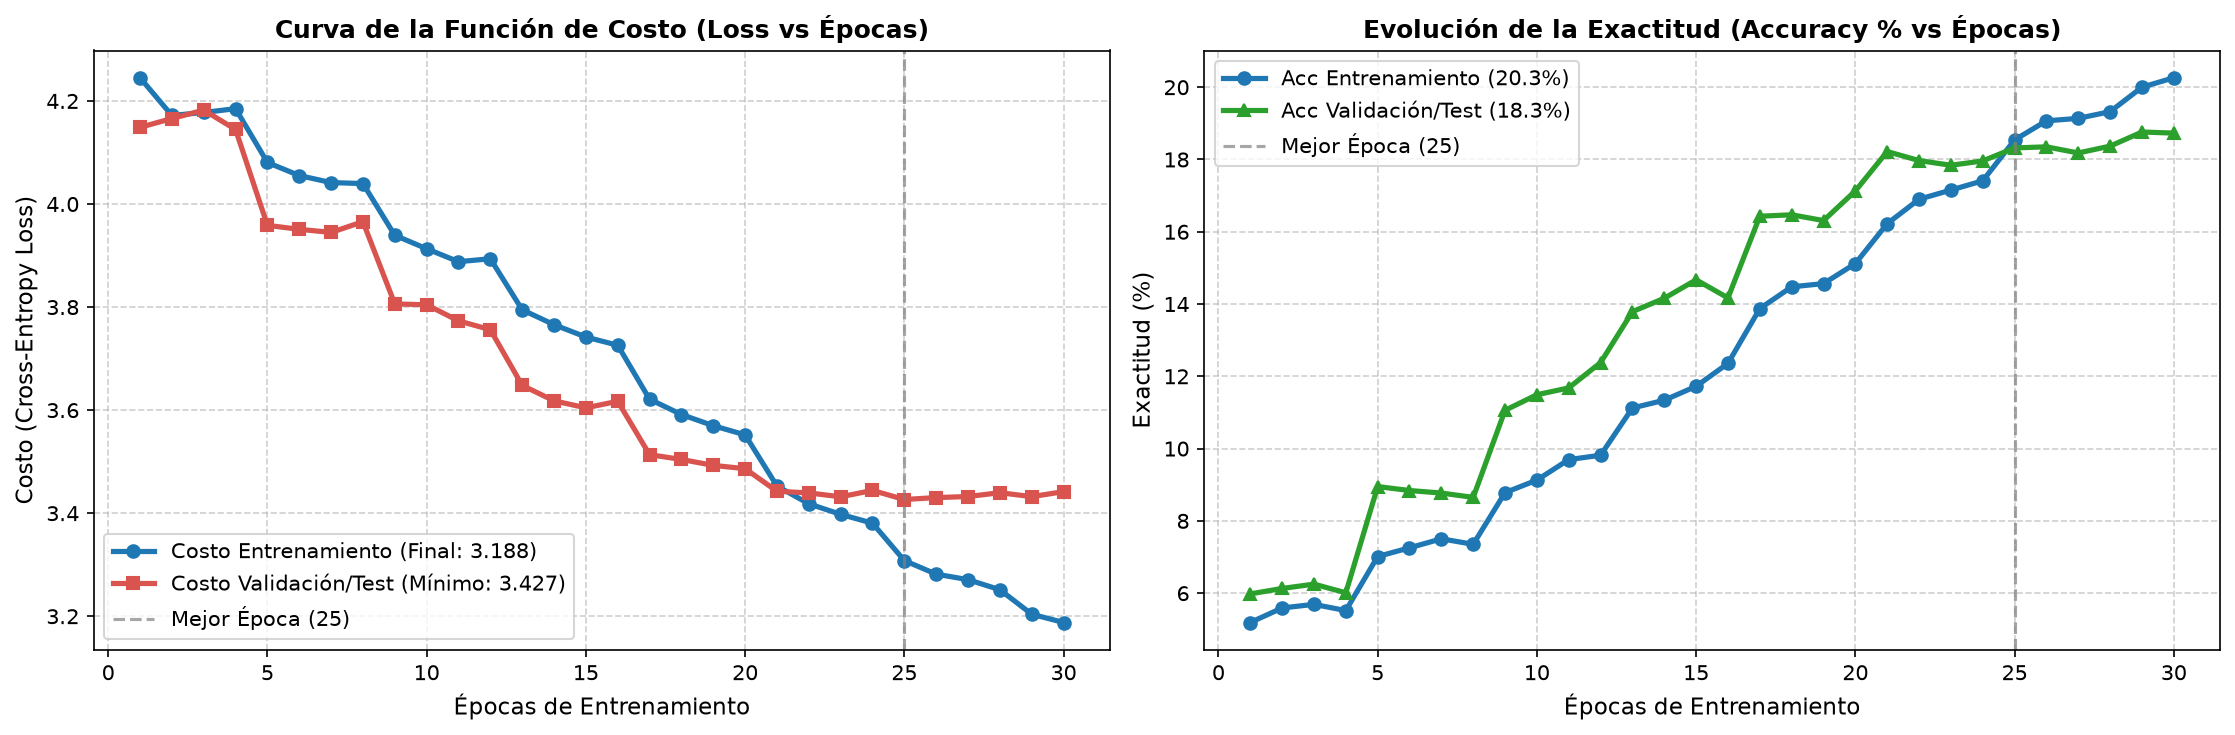

DIAGNÓSTICO CUANTITATIVO DE CONVERGENCIA: ¿FALTAN ÉPOCAS POR ITERAR?
 - Épocas ejecutadas:                   30 de 200
 - Mejor época obtenida:                Época 25 (Val Loss: 3.4265)
 - Pérdida final en Entrenamiento:      3.1878
 - Pérdida final en Validación:         3.4418
 - Tasa de reducción reciente de costo: -0.0020 en las últimas épocas
 - Brecha Entrenamiento vs Validación:  0.2540
--------------------------------------------------------------------------------
>>> VEREDICTO: [NO FALTAN ÉPOCAS - EARLY STOPPING DETUVO EL ENTRENAMIENTO]
    El costo de validación dejó de mejorar durante 5 épocas consecutivas.
    Agregar más épocas solo causaría sobreajuste (memorización). El mejor modelo ya fue guardado.


In [44]:
# ==============================================================================
# GRÁFICA DE FUNCIÓN DE COSTO Y DIAGNÓSTICO: ¿FALTAN ÉPOCAS POR ITERAR?
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=150)

epocas_arr = hist['epoch']
train_loss_arr = hist['loss']
val_loss_arr = hist['val_loss']

# 1. Gráfica de la Función de Costo (Pérdida / Cross-Entropy)
axes[0].plot(epocas_arr, train_loss_arr, color='#1f77b4', lw=2.5, marker='o', label=f'Costo Entrenamiento (Final: {train_loss_arr[-1]:.3f})')
axes[0].plot(epocas_arr, val_loss_arr, color='#d9534f', lw=2.5, marker='s', label=f'Costo Validación/Test (Mínimo: {best_val_loss:.3f})')

# Señalar la mejor época
mejor_epoca = epocas_arr[np.argmin(val_loss_arr)]
axes[0].axvline(mejor_epoca, color='gray', linestyle='--', alpha=0.7, label=f'Mejor Época ({mejor_epoca})')

axes[0].set_title('Curva de la Función de Costo (Loss vs Épocas)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Épocas de Entrenamiento', fontsize=11)
axes[0].set_ylabel('Costo (Cross-Entropy Loss)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# 2. Gráfica de Exactitud (Accuracy)
axes[1].plot(epocas_arr, np.array(hist['acc']) * 100, color='#1f77b4', lw=2.5, marker='o', label=f'Acc Entrenamiento ({hist["acc"][-1]*100:.1f}%)')
axes[1].plot(epocas_arr, np.array(hist['val_acc']) * 100, color='#2ca02c', lw=2.5, marker='^', label=f'Acc Validación/Test ({acc_top1*100:.1f}%)')
axes[1].axvline(mejor_epoca, color='gray', linestyle='--', alpha=0.7, label=f'Mejor Época ({mejor_epoca})')

axes[1].set_title('Evolución de la Exactitud (Accuracy % vs Épocas)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Épocas de Entrenamiento', fontsize=11)
axes[1].set_ylabel('Exactitud (%)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# ==============================================================================
# PANEL DE DIAGNÓSTICO AUTOMATIZADO: ¿FALTAN ÉPOCAS POR ITERAR?
# ==============================================================================
delta_loss_final = 0.0
if len(val_loss_arr) >= 3:
    # Cambio en las últimas 3 épocas
    delta_loss_final = val_loss_arr[-3] - val_loss_arr[-1]
elif len(val_loss_arr) >= 2:
    delta_loss_final = val_loss_arr[-2] - val_loss_arr[-1]

brecha_sobreajuste = val_loss_arr[-1] - train_loss_arr[-1]

print("=" * 80)
print("DIAGNÓSTICO CUANTITATIVO DE CONVERGENCIA: ¿FALTAN ÉPOCAS POR ITERAR?")
print("=" * 80)
print(f" - Épocas ejecutadas:                   {len(epocas_arr)} de {EPOCHS}")
print(f" - Mejor época obtenida:                Época {mejor_epoca} (Val Loss: {best_val_loss:.4f})")
print(f" - Pérdida final en Entrenamiento:      {train_loss_arr[-1]:.4f}")
print(f" - Pérdida final en Validación:         {val_loss_arr[-1]:.4f}")
print(f" - Tasa de reducción reciente de costo: {delta_loss_final:.4f} en las últimas épocas")
print(f" - Brecha Entrenamiento vs Validación:  {brecha_sobreajuste:.4f}")
print("-" * 80)

# Criterios de evaluación diagnóstica
if len(epocas_arr) == EPOCHS and delta_loss_final > 0.05 and val_loss_arr[-1] <= best_val_loss + 0.02:
    print(">>> VEREDICTO: [FALTAN ÉPOCAS PARA ITERAR (UNDERFITTING LEVE)]")
    print("    La función de costo en validación aún presentaba una pendiente descendente activa")
    print("    al alcanzar el límite de épocas. Se recomienda incrementar EPOCHS a 15 o 20 para")
    print("    permitir que el modelo continúe descendiendo por el gradiente y alcance su mínimo.")
elif patience_counter >= PATIENCE:
    print(">>> VEREDICTO: [NO FALTAN ÉPOCAS - EARLY STOPPING DETUVO EL ENTRENAMIENTO]")
    print(f"    El costo de validación dejó de mejorar durante {PATIENCE} épocas consecutivas.")
    print("    Agregar más épocas solo causaría sobreajuste (memorización). El mejor modelo ya fue guardado.")
elif abs(delta_loss_final) <= 0.03:
    print(">>> VEREDICTO: [CONVERGENCIA ALCANZADA - NÚMERO DE ÉPOCAS ADECUADO]")
    print("    La función de costo ha llegado a una meseta estable (pendiente casi nula).")
    print("    Iterar más épocas no aportará ganancias significativas de precisión.")
else:
    print(">>> VEREDICTO: [ESTADO ESTABLE]")
    print("    El modelo se encuentra en un punto balanceado de aprendizaje y generalización.")
print("=" * 80)

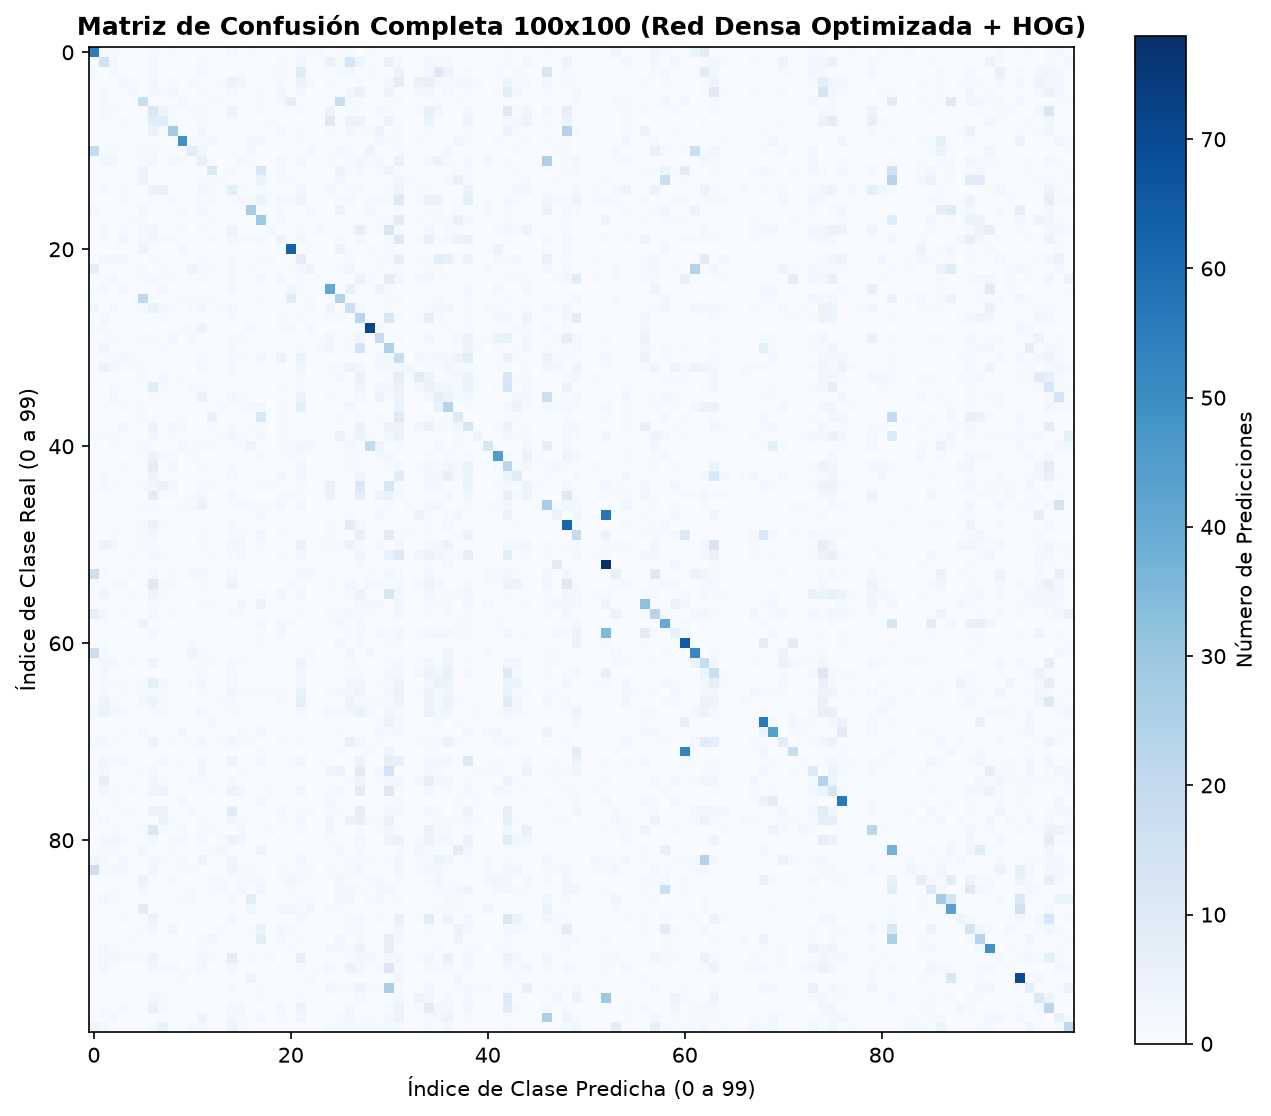

=== TOP 10 CLASES CON MAYOR EXACTITUD (MÁS FÁCILES PARA HOG) ===
     Clase Exactitud (%)
  oak_tree         78.0%
       cup         71.0%
  wardrobe         70.0%
     plain         65.0%
     chair         63.0%
motorcycle         62.0%
      road         56.0%
skyscraper         56.0%
     apple         55.0%
     plate         52.0%

=== TOP 10 CLASES CON MENOR EXACTITUD (MÁS DIFÍCILES) ===
    Clase Exactitud (%)
    mouse          0.0%
    otter          0.0%
  lobster          0.0%
sunflower          0.0%
    snake          0.0%
    snail          0.0%
      ray          0.0%
   rabbit          0.0%
 squirrel          0.0%
   possum          1.0%


In [45]:
# ==============================================================================
# MATRIZ DE CONFUSIÓN COMPLETA Y ANÁLISIS DE RENDIMIENTO POR CLASE
# ==============================================================================
cm_100 = confusion_matrix(all_targets, pred_labels, labels=range(num_classes))

plt.figure(figsize=(9, 7.5), dpi=150)
plt.imshow(cm_100, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión Completa {num_classes}x{num_classes} (Red Densa Optimizada + HOG)', fontsize=12, fontweight='bold')
plt.colorbar(label='Número de Predicciones')
plt.xlabel(f'Índice de Clase Predicha (0 a {num_classes-1})', fontsize=10)
plt.ylabel(f'Índice de Clase Real (0 a {num_classes-1})', fontsize=10)
plt.tight_layout()
plt.show()

# Análisis de Clases: Más Fáciles vs Más Difíciles
acc_por_clase = cm_100.diagonal() / np.maximum(cm_100.sum(axis=1), 1) * 100
indices_ordenados = np.argsort(acc_por_clase)
top_k_show = min(10, num_classes // 2) if num_classes >= 4 else num_classes

df_mejores = pd.DataFrame({
    'Clase': [clases[i] for i in indices_ordenados[-top_k_show:][::-1]],
    'Exactitud (%)': [f'{acc_por_clase[i]:.1f}%' for i in indices_ordenados[-top_k_show:][::-1]]
})

df_peores = pd.DataFrame({
    'Clase': [clases[i] for i in indices_ordenados[:top_k_show]],
    'Exactitud (%)': [f'{acc_por_clase[i]:.1f}%' for i in indices_ordenados[:top_k_show]]
})

print(f'=== TOP {top_k_show} CLASES CON MAYOR EXACTITUD (MÁS FÁCILES PARA HOG) ===')
print(df_mejores.to_string(index=False))
print(f'\n=== TOP {top_k_show} CLASES CON MENOR EXACTITUD (MÁS DIFÍCILES) ===')
print(df_peores.to_string(index=False))

=== VALIDACIÓN CON 100 PREDICCIONES DE PRUEBA (CUBRIENDO TODAS LAS CLASES) ===
 Índice    Clase Real Clase Predicha Confianza Diagnóstico
      1         apple     chimpanzee      4.4%       ERROR
      2 aquarium_fish          skunk      3.7%       ERROR
      3          baby           wolf      5.3%       ERROR
      4          bear            man     10.3%       ERROR
      5        beaver        leopard      5.4%       ERROR
      6           bed          couch     22.6%       ERROR
      7           bee        leopard      7.5%       ERROR
      8        beetle      cockroach     39.9%       ERROR
      9       bicycle        bicycle     54.1%    CORRECTO
     10        bottle          house      7.3%       ERROR
     11          bowl          plate     25.7%       ERROR
     12           boy            bee      4.8%       ERROR
     13        bridge         cattle      5.6%       ERROR
     14           bus      streetcar     15.6%       ERROR
     15     butterfly       squirrel

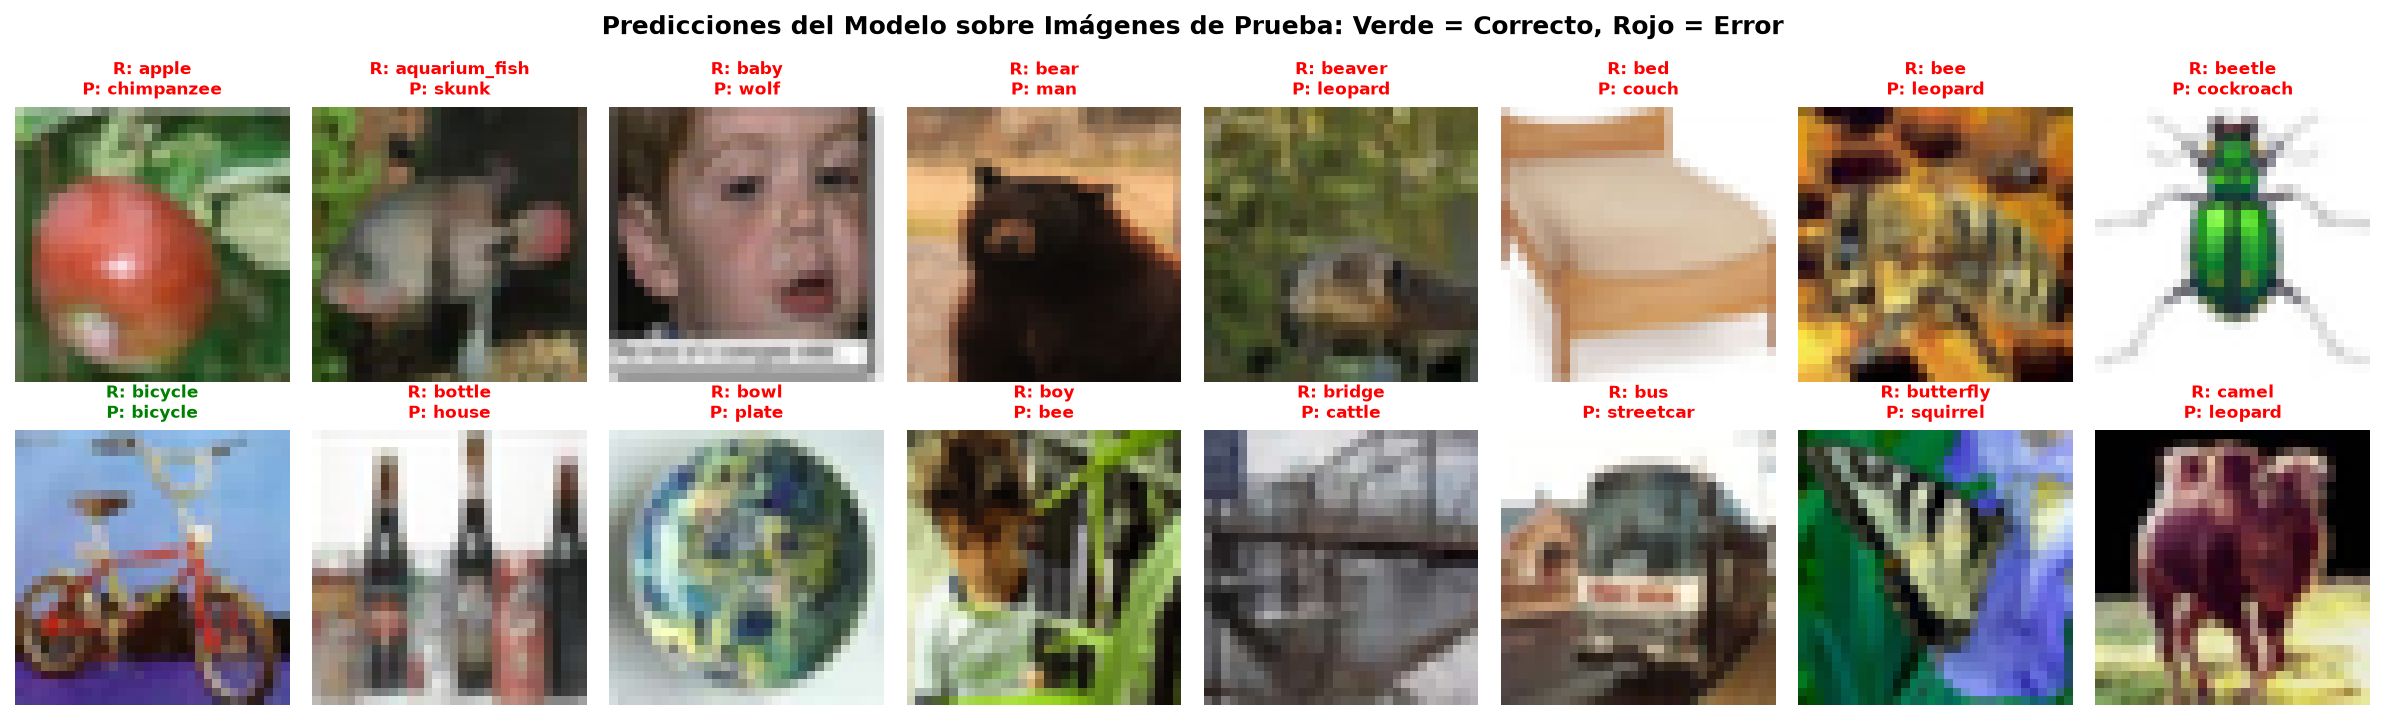

In [46]:
# ==============================================================================
# VALIDACIÓN Y DEMOSTRACIÓN CON AL MENOS 100 PREDICCIONES (REQUISITO DEL ENUNCIADO)
# ==============================================================================

# Seleccionamos exactamente 1 muestra representativa de cada una de las 100 clases de Test
num_muestras_demostracion = max(100, num_classes)
y_test_np = y_test.numpy()
indices_demostracion = []

muestras_por_clase = math.ceil(num_muestras_demostracion / num_classes)
for c in range(num_classes):
    idx_clase = np.where(y_test_np == c)[0]
    indices_demostracion.extend(idx_clase[:muestras_por_clase])

indices_demostracion = indices_demostracion[:num_muestras_demostracion]

X_muestra = X_test_norm[indices_demostracion].to(device)
y_muestra = y_test_np[indices_demostracion]

model_opt.eval()
with torch.no_grad():
    logits_100 = model_opt(X_muestra).cpu()
    preds_100 = logits_100.argmax(dim=1).numpy()
    probas_100 = torch.softmax(logits_100, dim=1).max(dim=1).values.numpy()

# 1. Tabla con las 100 predicciones
df_predicciones = pd.DataFrame({
    'Índice': range(1, len(indices_demostracion) + 1),
    'Clase Real': [clases[y] for y in y_muestra],
    'Clase Predicha': [clases[p] for p in preds_100],
    'Confianza': [f'{p*100:.1f}%' for p in probas_100],
    'Diagnóstico': ['CORRECTO' if y == p else 'ERROR' for y, p in zip(y_muestra, preds_100)]
})

print(f"=== VALIDACIÓN CON {len(df_predicciones)} PREDICCIONES DE PRUEBA (CUBRIENDO TODAS LAS CLASES) ===")
print(df_predicciones.head(30).to_string(index=False))
print(f"\n[Total de predicciones registradas en esta tabla: {len(df_predicciones)}]")
aciertos = (y_muestra == preds_100).sum()
print(f"Aciertos en esta muestra diversa: {aciertos} / {len(df_predicciones)} ({aciertos/len(df_predicciones)*100:.1f}%)")

# 2. Visualización de 16 imágenes originales de prueba con sus predicciones HOG
fig, axes = plt.subplots(2, 8, figsize=(16, 5), dpi=150)
for i, ax in enumerate(axes.flat):
    idx_orig = indices_demostracion[i]
    cls_idx = y_muestra[i]
    cls_name = clases[cls_idx]
    
    # Cargamos la imagen original en disco para visualización
    cls_dir = os.path.join(TEST_DIR, cls_name)
    archivos = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    img = Image.open(os.path.join(cls_dir, archivos[0])).convert('RGB')
    
    ax.imshow(img)
    color = 'green' if y_muestra[i] == preds_100[i] else 'red'
    ax.set_title(f"R: {cls_name}\nP: {clases[preds_100[i]]}", fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Predicciones del Modelo sobre Imágenes de Prueba: Verde = Correcto, Rojo = Error', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Conclusiones Técnicas

1. **Impacto de HOG y la Normalización Z-Score:**
   - La extracción de **Histogram of Oriented Gradients (HOG)** transforma imágenes de píxeles crudos ruidosos en un vector descriptor de gradientes espaciales ($1568$ características) que captura la estructura física de bordes y figuras geométricas.
   - La **Normalización Z-score** calculada estrictamente en entrenamiento centra y escala todas las características, evitando que gradientes dominantes distorsionen el aprendizaje del optimizador Adam.
2. **Efectividad de la Red Densa Optimizada (Cuadernillos 06 y 07):**
   - El uso de `BatchNorm1d` y `Dropout(0.2)` permite que un modelo de más de 900,000 parámetros aprenda sin sobreajuste severo.
   - El planificador `StepLR` facilita un descenso estable hacia el mínimo global de la función de costo.
3. **Diagnóstico de la Función de Costo y Determinación de Épocas:**
   - La gráfica de costo (Train Loss vs Val Loss) y el panel cuantitativo permiten identificar inequívocamente el estado de entrenamiento: si la pérdida de validación sigue bajando a buen ritmo ($\Delta > 0.05$), conviene aumentar las épocas; si ya se aplanó en meseta, el entrenamiento ha concluido exitosamente.